# `2.bell-biased` — Toy ISA + parametric gates

This notebook is the MLIR-stack counterpart of
[examples/2.bell-biased.ipynb](../../examples/2.bell-biased.ipynb).

It exercises three new pieces:

1. The **toy ISA dialect** (`flip`, `mix`, `entangle`, `skew(bias)`) —
   a small didactic alternative to Cliffords used by the legacy
   notebook.
2. **Parametric gates**. `skew(bias)` is the first qstack-MLIR gate that
   takes a non-qubit argument; the surface grammar accepts
   `IDENT "(" NUMBER, ... ")" qubit_arg, ...` and the dialect carries
   the parameter as an `f64` attribute.
3. **Biased Bell state**. `skew(0.8)` prepares
   $\sqrt{0.8}\,|0\rangle + i\sqrt{0.2}\,|1\rangle$ on the control wire;
   the `entangle` (CNOT) then yields a biased Bell state with
   $|11\rangle\approx 80\%$.

In [1]:
%load_ext qstack_mlir.jupyter

In [2]:
%%qasm biased
QSTACKQASM 0.1;
include "qstack/toy.inc";

qreg q[2];
creg c[2];
skew(0.8) q[0];
entangle q[0], q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];

<ModuleOp 4639021904(operands=[], results=[], successors=[], properties={}, attributes={}, regions=[<Region 4639015712>], parent=None, _next_op=None, _prev_op=None)>

## Lowered IR

Notice the `toy.skew` op carries `bias = 8.000000e-01 : f64` as a
property — that's the only piece of the program that depends on the
classical parameter.

In [3]:
print(biased)

builtin.module {
  func.func @main() -> (!qstack.bit, !qstack.bit) {
    %0, %1 = qstack.kernel {
    ^bb0(%2: !qstack.qubit, %3: !qstack.qubit):
      %4 = "toy.skew"(%2) <{bias = 8.000000e-01 : f64}> : (!qstack.qubit) -> !qstack.qubit
      %5, %6 = "toy.entangle"(%4, %3) : (!qstack.qubit, !qstack.qubit) -> (!qstack.qubit, !qstack.qubit)
      %7 = qstack.measure %5
      %8 = qstack.measure %6
      qstack.return %7, %8 : !qstack.bit, !qstack.bit
    } : () -> !qstack.bit, !qstack.bit
    func.return %0, %1 : !qstack.bit, !qstack.bit
  }
}


## Run

The emulator dispatches `toy.skew` by reading the `bias` attribute and
synthesising the corresponding unitary at run time, so changing the
bias requires no recompilation of the IR — only the attribute value.

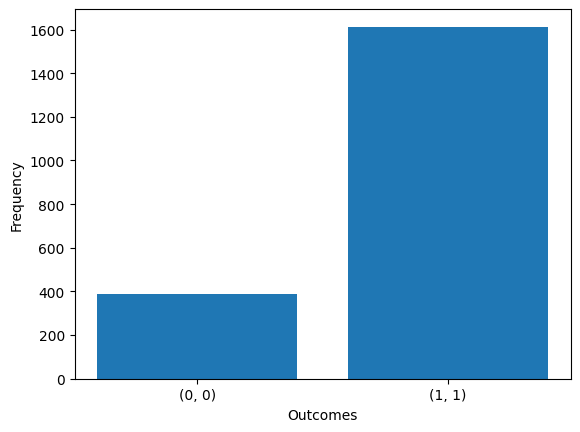

<Axes: xlabel='Outcomes', ylabel='Frequency'>

Failed to post telemetry. Pending metrics will be retried at the next interval.
Traceback (most recent call last):
  File "/Users/anpaz/Repos/.venv/qstack/lib/python3.12/site-packages/qsharp/telemetry.py", line 269, in _telemetry_thread_start
    msg = telemetry_queue.get(timeout=timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
_queue.Empty

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/Cellar/python@3.12/3.12.7_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/urllib/request.py", line 1344, in do_open
    h.request(req.get_method(), req.selector, req.data, headers,
  File "/usr/local/Cellar/python@3.12/3.12.7_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/http/client.py", line 1336, in request
    self._send_request(method, url, body, headers, encode_chunked)
  File "/usr/local/Cellar/python@3.12/3.12.7_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/http/client.py", lin

In [4]:
from qstack_mlir.runtime import Machine

machine = Machine(biased, num_qubits=4)
results = machine.shots("main", 2000)
results.plot_histogram()

The histogram concentrates on $(0,0)$ and $(1,1)$ (the entangled Bell
manifold), with the $(1,1)$ outcome taking ~80% of the population —
exactly the `bias` we asked for.